In [1]:
!pip install torch pandas numpy scikit-learn

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import json
import os
import gc
import copy
import warnings
import matplotlib.pyplot as plt


In [16]:

warnings.filterwarnings('ignore')

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Device: {device}")


BASE_PATH = r"/content/drive/MyDrive/exercise_danger_data "

# File paths
MATH_PATH = os.path.join(BASE_PATH, "math_model_predictions.csv")
CLUSTER_PATH = os.path.join(BASE_PATH, "cluster_assignments.csv")
GRAPH_PATH = os.path.join(BASE_PATH, "gnn_graph_data.json")

# Output path
OUTPUT_PATH = os.path.join(BASE_PATH, "FINAL_EXERCISE_DANGER_SCORES_R.csv")

print(f"📂 Base Path: {BASE_PATH}")
print(f"   Math: {os.path.exists(MATH_PATH)}")
print(f"   Cluster: {os.path.exists(CLUSTER_PATH)}")
print(f"   Graph: {os.path.exists(GRAPH_PATH)}")

 Device: cuda
📂 Base Path: /content/drive/MyDrive/exercise_danger_data 
   Math: True
   Cluster: True
   Graph: True


In [ ]:
# GNN MODEL DEFINITION

class SimpleGCNLayer(nn.Module):
    """Simple Graph Convolutional Layer."""
    def __init__(self, in_features, out_features):
        super(SimpleGCNLayer, self).__init__()
        self.linear = nn.Linear(in_features, out_features)

    def forward(self, x, adj):
        neighbor_aggr = torch.mm(adj, x)
        output = self.linear(neighbor_aggr)
        return output


class RegionalRiskGNN(nn.Module):
    def __init__(self, num_features, hidden_dim=8):
        super(RegionalRiskGNN, self).__init__()
        self.gc1 = SimpleGCNLayer(num_features, hidden_dim)
        self.ln1 = nn.LayerNorm(hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.7)
        self.gc2 = SimpleGCNLayer(hidden_dim, 1)

    def forward(self, x, adj):
        x = self.gc1(x, adj)
        x = self.ln1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.gc2(x, adj)
        return x


In [ ]:
class ExerciseDangerGNNSystem:
    def __init__(self):
        self.model = None
        self.adj_matrix = None
        self.node_features = None
        self.node_targets = None
        self.cluster_map = None
        self.merged_df = None
        self.global_mean_score = 50.0
        self.train_mask = None
        self.val_mask = None
        self.history = None

    def optimize_df(self, df):
        fcols = df.select_dtypes('float').columns
        icols = df.select_dtypes('integer').columns
        df[fcols] = df[fcols].apply(pd.to_numeric, downcast='float')
        df[icols] = df[icols].apply(pd.to_numeric, downcast='integer')
        return df

    def load_and_prep_data(self, augment=True, n_augments=5):
        print("Loading Data...")

        df_math = pd.read_csv(MATH_PATH)
        df_math = self.optimize_df(df_math)
        print(f"Math predictions: {len(df_math)} locations")

        df_cluster = pd.read_csv(CLUSTER_PATH)
        df_cluster = self.optimize_df(df_cluster)
        print(f"Cluster assignments: {len(df_cluster)} locations")
        print(f"Columns: {df_cluster.columns.tolist()}")

        self.merged_df = pd.merge(df_math, df_cluster, on='location_name', how='inner')
        self.merged_df = self.merged_df.drop_duplicates(subset=['location_name'], keep='first').reset_index(drop=True)
        print(f"Merged data: {len(self.merged_df)} locations (deduplicated)")

        with open(GRAPH_PATH, 'r') as f:
            graph_data = json.load(f)
        print(f"Graph: {len(graph_data['node_ids'])} nodes")

        self.merged_df['location_name_clean'] = self.merged_df['location_name'].astype(str).str.strip().str.lower()
        self.merged_df = self.merged_df[self.merged_df['location_name_clean'] != '']

        graph_node_ids_clean = []
        for name in graph_data['node_ids']:
            clean = str(name).strip().lower()
            if clean:
                graph_node_ids_clean.append(clean)
            else:
                graph_node_ids_clean.append('unknown')

        print("Cleaned location names for matching.")

        merged_lookup = {}
        for idx, row in self.merged_df.iterrows():
            clean_name = row['location_name_clean']
            if clean_name not in merged_lookup:
                merged_lookup[clean_name] = idx

        print(f"Merged lookup has {len(merged_lookup)} unique entries")

        aligned_math_scores = []
        aligned_clusters = []
        aligned_features = []
        aligned_location_names = []
        aligned_merged_indices = []

        graph_node_ids = graph_data['node_ids']
        exact_match_count = 0
        unmatched_examples = []

        for node_idx, node_name in enumerate(graph_node_ids):
            clean_node_name = str(node_name).strip().lower()
            base_name = clean_node_name.split('|')[0].strip()

            if base_name in merged_lookup:
                merged_idx = merged_lookup[base_name]
                row = self.merged_df.iloc[merged_idx]
                aligned_math_scores.append(float(row['math_danger_score']))
                aligned_clusters.append(int(row['cluster']))
                aligned_location_names.append(str(row['location_name']))
                aligned_merged_indices.append(merged_idx)
                aligned_features.append(graph_data['node_features'][node_idx])
                exact_match_count += 1
            else:
                default_math = self.merged_df['math_danger_score'].mean() if len(self.merged_df) > 0 else 50.0
                aligned_math_scores.append(float(default_math))
                aligned_clusters.append(-1)
                aligned_location_names.append(str(node_name))
                aligned_merged_indices.append(-1)
                aligned_features.append(graph_data['node_features'][node_idx])
                if len(unmatched_examples) < 10:
                    unmatched_examples.append(str(node_name))

        matched_count = exact_match_count
        unmatched_count = len(graph_node_ids) - exact_match_count
        if unmatched_count > 0:
            print(f"{unmatched_count} graph nodes had no exact CSV match and are using default values")
            print(f"Examples: {unmatched_examples}")

        self.merged_df = pd.DataFrame({
            'location_name': aligned_location_names,
            'cluster': aligned_clusters,
            'math_danger_score': aligned_math_scores,
            'original_merged_idx': aligned_merged_indices,
        })

        feature_cols = ['air_quality_PM2.5', 'temperature_celsius', 'air_quality_us-epa-index', 'uv_index']

        for col in feature_cols:
            if col in df_cluster.columns:
                feature_map = {}
                for idx, row in df_cluster.iterrows():
                    feature_map[idx] = {
                        'air_quality_PM2.5': float(row.get('air_quality_PM2.5', 10.0)),
                        'temperature_celsius': float(row.get('temperature_celsius', 20.0)),
                        'air_quality_us-epa-index': float(row.get('air_quality_us-epa-index', 1.0)),
                        'uv_index': float(row.get('uv_index', 3.0)),
                    }

                feature_values = []
                for idx in range(len(self.merged_df)):
                    orig_idx = self.merged_df.iloc[idx]['original_merged_idx']
                    if orig_idx >= 0 and orig_idx in feature_map:
                        feature_values.append(feature_map[orig_idx][col])
                    else:
                        if col == 'air_quality_PM2.5':
                            feature_values.append(10.0)
                        elif col == 'temperature_celsius':
                            feature_values.append(20.0)
                        elif col == 'air_quality_us-epa-index':
                            feature_values.append(1.0)
                        elif col == 'uv_index':
                            feature_values.append(3.0)

                self.merged_df[col] = feature_values

        for col in feature_cols:
            if col not in self.merged_df.columns:
                if col == 'air_quality_PM2.5':
                    self.merged_df[col] = 10.0
                elif col == 'temperature_celsius':
                    self.merged_df[col] = 20.0
                elif col == 'air_quality_us-epa-index':
                    self.merged_df[col] = 1.0
                elif col == 'uv_index':
                    self.merged_df[col] = 3.0

        print(f"Aligned data: {len(self.merged_df)} locations (matching graph nodes)")
        print(f"Exact matches: {matched_count} / {len(self.merged_df)}")

        self.adj_matrix = torch.tensor(graph_data['adjacency_matrix'], dtype=torch.float32).to(device)

        raw_features = torch.tensor(graph_data['node_features'], dtype=torch.float32)
        mean = raw_features.mean(dim=0, keepdim=True)
        std = raw_features.std(dim=0, keepdim=True)
        self.node_features = (raw_features - mean) / (std + 1e-6)
        self.node_features = self.node_features.to(device)

        threshold = 0.7
        self.adj_matrix[self.adj_matrix < threshold] = 0
        self.adj_matrix.fill_diagonal_(1.0)
        row_sums = self.adj_matrix.sum(1)
        row_sums[row_sums == 0] = 1
        self.adj_matrix = self.adj_matrix / row_sums[:, None]

        self.global_mean_score = self.merged_df['math_danger_score'].mean()
        residuals = self.merged_df['math_danger_score'].values - self.global_mean_score

        n_orig = len(self.merged_df)
        orig_indices = torch.randperm(n_orig)
        orig_split = int(0.8 * n_orig)
        orig_train_idx = orig_indices[:orig_split]
        orig_val_idx = orig_indices[orig_split:]

        if augment:
            print(f"Applying location-level augmentation (x{n_augments})...")

            aug_features = []
            aug_targets = []

            print(f"Original nodes for augmentation: {n_orig}")

            for i in range(n_orig):
                aug_features.append(self.node_features[i].cpu().numpy())
                aug_targets.append(residuals[i])

                for _ in range(n_augments - 1):
                    noise = np.random.randn(self.node_features.shape[1]) * 0.1
                    aug_features.append(self.node_features[i].cpu().numpy() + noise)
                    aug_targets.append(residuals[i])

            self.node_features = torch.tensor(np.array(aug_features), dtype=torch.float32).to(device)
            self.node_targets = torch.tensor(aug_targets, dtype=torch.float32).view(-1, 1).to(device)

            print(f"Augmented nodes: {len(aug_features)}")

            n_aug = n_orig * n_augments
            aug_adj = torch.zeros(n_aug, n_aug).to(device)

            for i in range(n_orig):
                for j in range(n_orig):
                    if self.adj_matrix[i, j] > 0:
                        for k in range(n_augments):
                            for l in range(n_augments):
                                idx_i = i * n_augments + k
                                idx_j = j * n_augments + l
                                aug_adj[idx_i, idx_j] = self.adj_matrix[i, j] * 0.8

            for i in range(n_aug):
                aug_adj[i, i] = 1.0

            self.adj_matrix = aug_adj
            print(f"Augmented adjacency: {n_aug} x {n_aug}")

        else:
            self.node_targets = torch.tensor(residuals, dtype=torch.float32).view(-1, 1).to(device)

        num_nodes = self.node_features.size(0)
        if augment:
            reps = num_nodes // n_orig
            train_list = [orig_train_idx * reps + k for k in range(reps)]
            val_list = [orig_val_idx * reps + k for k in range(reps)]
            self.train_mask = torch.cat(train_list)
            self.val_mask = torch.cat(val_list)
        else:
            self.train_mask = orig_train_idx
            self.val_mask = orig_val_idx

        print(f"Train/Val split: {len(self.train_mask)} / {len(self.val_mask)} nodes")
        print(f"Data Ready: {num_nodes} nodes.")

    def train_gnn_with_monitoring(self, epochs=3000):
        print("\nTraining GNN with Monitoring...")

        num_features = self.node_features.shape[1]
        print(f"Features: {num_features}")
        print(f"Training nodes: {len(self.train_mask)}")
        print(f"Validation nodes: {len(self.val_mask)}")

        t_mean = self.node_targets[self.train_mask].mean()
        t_std = self.node_targets[self.train_mask].std()

        if t_std < 1e-6:
            t_std = 1.0
            print(f"Target std is 0, setting to 1.0")

        norm_targets = (self.node_targets - t_mean) / (t_std + 1e-6)

        self.model = RegionalRiskGNN(num_features, hidden_dim=8).to(device)
        criterion = nn.SmoothL1Loss()
        optimizer = optim.Adam(self.model.parameters(), lr=0.001, weight_decay=5e-3)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=50)

        best_val_loss = float('inf')
        best_model_state = None
        patience = 100
        patience_counter = 0

        history = {
            'epoch': [],
            'train_loss': [],
            'val_loss': [],
            'learning_rate': []
        }

        for epoch in range(epochs):
            self.model.train()
            optimizer.zero_grad()

            noise = torch.randn_like(self.node_features) * 0.1
            aug_features = self.node_features + noise

            edge_mask = torch.rand_like(self.adj_matrix) > 0.3
            aug_adj = self.adj_matrix * edge_mask.float()
            row_sums = aug_adj.sum(1)
            row_sums[row_sums == 0] = 1
            aug_adj = aug_adj / row_sums[:, None]

            outputs = self.model(aug_features, aug_adj)
            train_loss = criterion(outputs[self.train_mask], norm_targets[self.train_mask])
            train_loss.backward()
            optimizer.step()

            self.model.eval()
            with torch.no_grad():
                val_outputs = self.model(self.node_features, self.adj_matrix)
                val_loss = criterion(val_outputs[self.val_mask], norm_targets[self.val_mask])

            scheduler.step(val_loss)

            current_lr = optimizer.param_groups[0]['lr']
            history['epoch'].append(epoch + 1)
            history['train_loss'].append(train_loss.item())
            history['val_loss'].append(val_loss.item())
            history['learning_rate'].append(current_lr)

            if (epoch + 1) % 200 == 0:
                print(f"Epoch {epoch+1:4d} | Train: {train_loss.item():.4f} | Val: {val_loss.item():.4f} | LR: {current_lr:.6f}")

            if val_loss.item() < best_val_loss:
                best_val_loss = val_loss.item()
                best_model_state = copy.deepcopy(self.model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early Stopping at Epoch {epoch+1}")
                    break

        if best_model_state:
            self.model.load_state_dict(best_model_state)

        self.model.eval()

        class DenormalizedModel(nn.Module):
            def __init__(self, base, m, s):
                super().__init__()
                self.base = base
                self.mean = m
                self.std = s
            def forward(self, x, adj):
                return (self.base(x, adj) * self.std) + self.mean

        self.model = DenormalizedModel(self.model, t_mean, t_std)
        self.history = history
        print(f"Training Done. Best Val Loss: {best_val_loss:.4f}")

        return history

    def apply_adjustments(self):
        print("\nApplying Adjustments...")

        self.model.eval()
        with torch.no_grad():
            preds = self.model(self.node_features, self.adj_matrix).cpu().numpy().flatten()

        n_orig = len(self.merged_df)
        n_aug = len(preds)
        aug_per_node = n_aug // n_orig if n_orig > 0 else 0

        if aug_per_node > 1:
            print(f"Aggregating {aug_per_node} augmentations per location...")
            avg_preds = []
            for i in range(n_orig):
                start = i * aug_per_node
                end = start + aug_per_node
                avg_preds.append(np.mean(preds[start:end]))
        else:
            avg_preds = preds[:n_orig]

        cluster_biases = {}
        for idx, row in self.merged_df.iterrows():
            cluster = row['cluster']
            if cluster not in cluster_biases:
                cluster_biases[cluster] = []
            cluster_biases[cluster].append(avg_preds[idx])

        self.cluster_map = {}
        for cluster, biases in cluster_biases.items():
            self.cluster_map[cluster] = np.mean(biases)

        if len(avg_preds) != len(self.merged_df):
            raise ValueError(f"Mismatch: avg_preds ({len(avg_preds)}) and merged_df ({len(self.merged_df)}) have different lengths.")

        self.merged_df['gnn_bias'] = avg_preds

        self.merged_df['final_danger_score'] = (
            self.merged_df['math_danger_score'] + self.merged_df['gnn_bias']
        )
        self.merged_df['final_danger_score'] = self.merged_df['final_danger_score'].clip(0, 100)

        conditions = [
            (self.merged_df['final_danger_score'] >= 80),
            (self.merged_df['final_danger_score'] >= 60),
            (self.merged_df['final_danger_score'] >= 40),
            (self.merged_df['final_danger_score'] >= 20)
        ]
        choices = ['EXTREME DANGER', 'HIGH RISK', 'MODERATE RISK', 'LOW RISK']
        self.merged_df['final_category'] = np.select(conditions, choices, default='SAFE')

        print(f"GNN biases applied")
        print(f"Final scores: {self.merged_df['final_danger_score'].min():.1f} - {self.merged_df['final_danger_score'].max():.1f}")
        print(f"Mean final score: {self.merged_df['final_danger_score'].mean():.1f}")

    def save_final_output(self):
        print(f"\nSaving to {OUTPUT_PATH}...")

        os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

        cols = [
            'location_name', 'cluster',
            'air_quality_PM2.5', 'temperature_celsius',
            'air_quality_us-epa-index', 'uv_index',
            'math_danger_score', 'gnn_bias',
            'final_danger_score', 'final_category'
        ]

        save_cols = [c for c in cols if c in self.merged_df.columns]
        self.merged_df[save_cols].to_csv(OUTPUT_PATH, index=False)

        print(f"Success! Saved {len(self.merged_df)} rows to {OUTPUT_PATH}")
        print(f"Columns: {save_cols}")

    def get_bias_map(self):
        return self.cluster_map

In [19]:
# ============================================================================
# VISUALIZATION FUNCTIONS
# ============================================================================

def plot_training_history(system, save_path=None):
    """
    Plot training and validation loss curves.
    """
    if not hasattr(system, 'history') or not system.history:
        print("⚠️ No training history found. Train the model first.")
        return

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('GNN Training History', fontsize=16, fontweight='bold')

    history = system.history
    epochs = history['epoch']

    # Plot 1: Loss curves
    ax1 = axes[0, 0]
    ax1.plot(epochs, history['train_loss'], label='Train Loss', linewidth=2, color='blue')
    ax1.plot(epochs, history['val_loss'], label='Validation Loss', linewidth=2, color='red', linestyle='--')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training vs Validation Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    best_val_idx = np.argmin(history['val_loss'])
    ax1.axvline(x=best_val_idx + 1, color='green', linestyle=':', alpha=0.5,
                label=f'Best Val: Epoch {best_val_idx + 1}')
    ax1.legend()

    # Plot 2: Loss (log scale)
    ax2 = axes[0, 1]
    ax2.semilogy(epochs, history['train_loss'], label='Train Loss', linewidth=2, color='blue')
    ax2.semilogy(epochs, history['val_loss'], label='Validation Loss', linewidth=2, color='red', linestyle='--')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss (log scale)')
    ax2.set_title('Loss (Log Scale)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Plot 3: Loss difference
    ax3 = axes[1, 0]
    loss_diff = np.array(history['val_loss']) - np.array(history['train_loss'])
    ax3.plot(epochs, loss_diff, linewidth=2, color='purple')
    ax3.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Val - Train Loss')
    ax3.set_title('Overfitting Indicator (Val - Train)')
    ax3.grid(True, alpha=0.3)

    # Plot 4: Learning Rate
    ax4 = axes[1, 1]
    ax4.plot(epochs, history['learning_rate'], linewidth=2, color='green')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Learning Rate')
    ax4.set_title('Learning Rate Schedule')
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"📊 Figure saved to: {save_path}")

    plt.show()
    return fig


def plot_predictions_vs_targets(system, save_path=None):
    """
    Plot predicted biases vs actual targets for validation set.
    """
    if system.model is None:
        print("⚠️ Model not trained yet.")
        return

    system.model.eval()
    with torch.no_grad():
        preds = system.model(system.node_features, system.adj_matrix).cpu().numpy().flatten()

    targets = system.node_targets.cpu().numpy().flatten()

    val_targets = targets[system.val_mask.cpu().numpy()]
    val_preds = preds[system.val_mask.cpu().numpy()]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Scatter plot
    ax1 = axes[0]
    ax1.scatter(val_targets, val_preds, alpha=0.6, edgecolors='k', linewidth=0.5)
    ax1.plot([min(val_targets), max(val_targets)],
             [min(val_targets), max(val_targets)],
             'r--', linewidth=2, label='Perfect Prediction')
    ax1.set_xlabel('Actual Bias')
    ax1.set_ylabel('Predicted Bias')
    ax1.set_title('Validation: Predicted vs Actual')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    corr = np.corrcoef(val_targets, val_preds)[0, 1]
    mae = np.mean(np.abs(val_targets - val_preds))
    ax1.text(0.05, 0.95, f'Correlation: {corr:.3f}\nMAE: {mae:.3f}',
             transform=ax1.transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Residual histogram
    ax2 = axes[1]
    residuals = val_targets - val_preds
    ax2.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
    ax2.axvline(x=0, color='red', linestyle='--', linewidth=2)
    ax2.set_xlabel('Residual (Actual - Predicted)')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Residual Distribution')
    ax2.grid(True, alpha=0.3)

    std_res = np.std(residuals)
    ax2.text(0.05, 0.95, f'Mean: {np.mean(residuals):.3f}\nStd: {std_res:.3f}',
             transform=ax2.transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"📊 Figure saved to: {save_path}")

    plt.show()
    return fig


def visualize_graph_predictions(system, save_path=None):
    """
    Visualize the graph with node colors representing GNN biases.
    """
    if system.model is None:
        print("⚠️ Model not trained yet.")
        return

    system.model.eval()
    with torch.no_grad():
        preds = system.model(system.node_features, system.adj_matrix).cpu().numpy().flatten()

    n_orig = len(system.merged_df)
    n_aug = len(preds)
    aug_per_node = n_aug // n_orig if n_orig > 0 else 0

    if aug_per_node > 1:
        avg_preds = []
        for i in range(n_orig):
            start = i * aug_per_node
            end = start + aug_per_node
            avg_preds.append(np.mean(preds[start:end]))
        final_preds = np.array(avg_preds)
    else:
        final_preds = preds[:n_orig]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Bias distribution
    ax1 = axes[0]
    ax1.hist(final_preds, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Bias')
    ax1.axvline(x=np.mean(final_preds), color='green', linestyle='--', linewidth=2,
                label=f'Mean: {np.mean(final_preds):.2f}')
    ax1.set_xlabel('GNN Bias')
    ax1.set_ylabel('Frequency')
    ax1.set_title('GNN Bias Distribution')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Bias by cluster
    ax2 = axes[1]
    cluster_biases = {}
    for idx, row in system.merged_df.iterrows():
        cluster = row['cluster']
        if cluster not in cluster_biases:
            cluster_biases[cluster] = []
        cluster_biases[cluster].append(final_preds[idx])

    clusters = sorted(cluster_biases.keys())
    means = [np.mean(cluster_biases[c]) for c in clusters]
    stds = [np.std(cluster_biases[c]) for c in clusters]

    ax2.bar(clusters, means, yerr=stds, capsize=5, alpha=0.7,
            color='coral', edgecolor='black')
    ax2.axhline(y=0, color='red', linestyle='--', linewidth=2)
    ax2.set_xlabel('Cluster ID')
    ax2.set_ylabel('GNN Bias')
    ax2.set_title('GNN Bias by Cluster')
    ax2.grid(True, alpha=0.3)

    for i, (c, m) in enumerate(zip(clusters, means)):
        ax2.text(i, m + (0.05 if m >= 0 else -0.05), f'{m:+.2f}',
                 ha='center', va='bottom' if m >= 0 else 'top', fontsize=9)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"📊 Figure saved to: {save_path}")

    plt.show()
    return fig


def print_training_summary(system):
    """Print a summary of the training run."""
    if not hasattr(system, 'history') or not system.history:
        print("⚠️ No training history found. Train the model first.")
        return

    history = system.history
    epochs = len(history['epoch'])

    best_val_idx = np.argmin(history['val_loss'])
    best_val_loss = history['val_loss'][best_val_idx]

    final_train_loss = history['train_loss'][-1]
    final_val_loss = history['val_loss'][-1]

    print("\n" + "=" * 60)
    print("📊 TRAINING SUMMARY")
    print("=" * 60)
    print(f"   Total Epochs:          {epochs}")
    print(f"   Best Validation Loss:  {best_val_loss:.4f} (Epoch {best_val_idx + 1})")
    print(f"   Final Train Loss:      {final_train_loss:.4f}")
    print(f"   Final Validation Loss: {final_val_loss:.4f}")
    print(f"   Overfitting Gap:       {final_val_loss - final_train_loss:.4f}")
    print("=" * 60)

    gap = final_val_loss - final_train_loss
    if gap < 0.1:
        print("   ✅ Model is well-behaved. No significant overfitting.")
    elif gap < 0.5:
        print("   ⚠️ Moderate overfitting detected. Consider increasing regularization.")
    else:
        print("   🔴 High overfitting detected. Add more augmentation or regularization.")

📂 Loading Data...
   ✅ Math predictions: 489 locations
   ✅ Cluster assignments: 489 locations
      Columns: ['location_name', 'cluster', 'air_quality_PM2.5', 'temperature_celsius', 'air_quality_us-epa-index', 'uv_index']
   ✅ Merged data: 267 locations (deduplicated)
   ✅ Graph: 489 nodes
   🧹 Cleaned location names for matching.
   📊 Merged lookup has 267 unique entries
   ✅ Aligned data: 489 locations (matching graph nodes)
      Exact matches: 489 / 489
   🔄 Applying location-level augmentation (x2)...
      Original nodes for augmentation: 489
      ✅ Augmented nodes: 978
      ✅ Augmented adjacency: 978 x 978
   ✅ Train/Val split: 782 / 196 nodes (391 / 98 distinct locations, no cross-leakage)
   • Data Ready: 978 nodes.

🧠 Training GNN with Monitoring...
   Features: 10
   Training nodes: 782
   Validation nodes: 196
   • Epoch  200 | Train: 0.2299 | Val: 0.2531 | LR: 0.000500
   ⏹ Early Stopping at Epoch 230
✅ Training Done. Best Val Loss: 0.2307

📊 TRAINING SUMMARY
   Total E

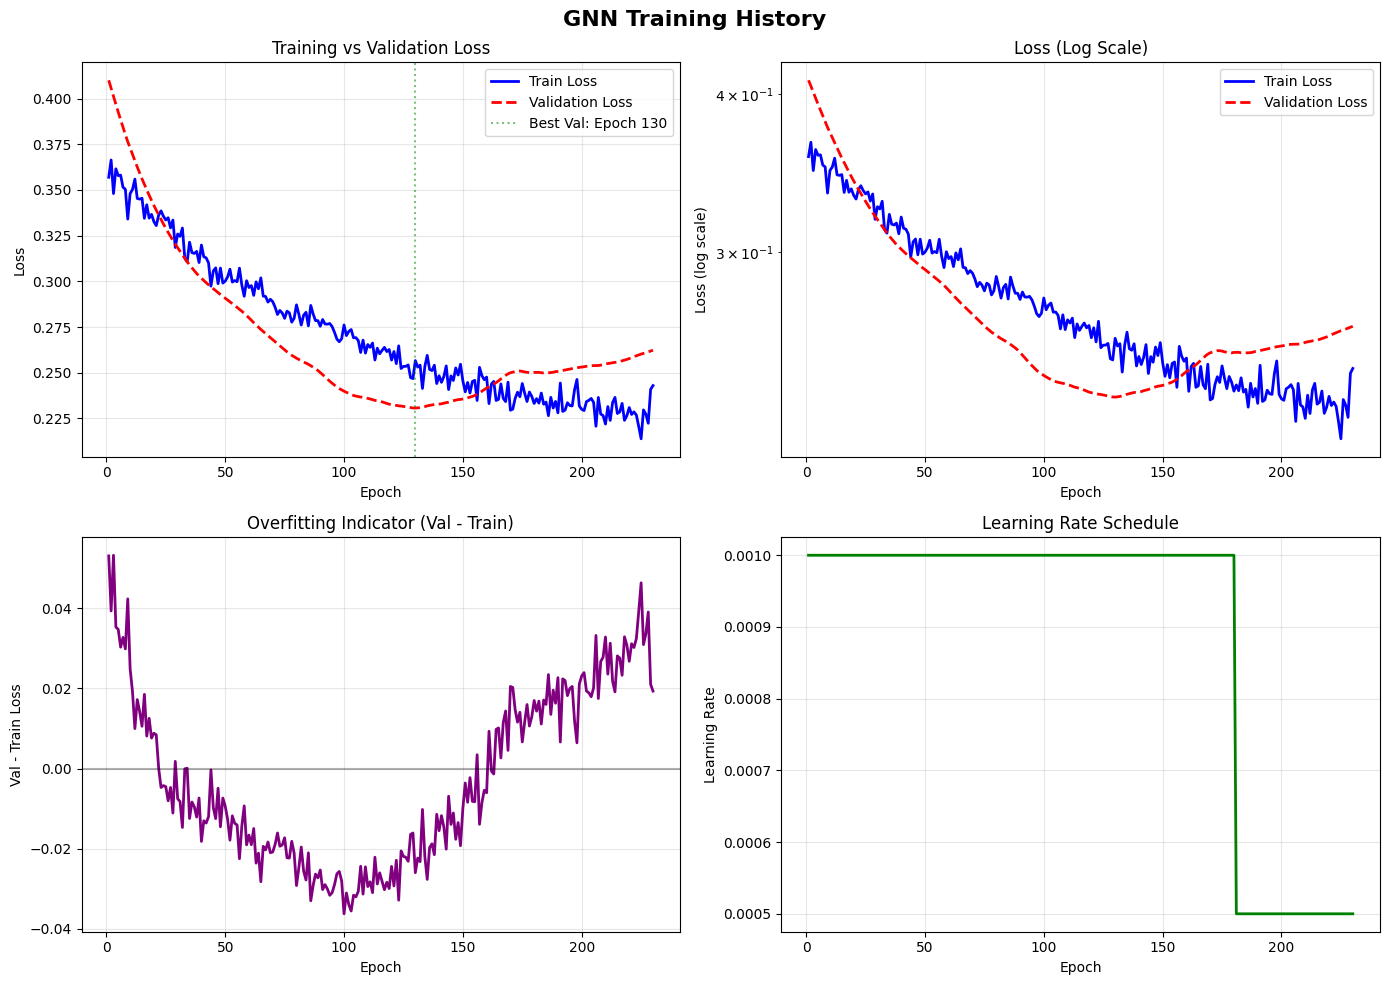

📊 Figure saved to: /content/drive/MyDrive/exercise_danger_data /predictions_vs_targets.png


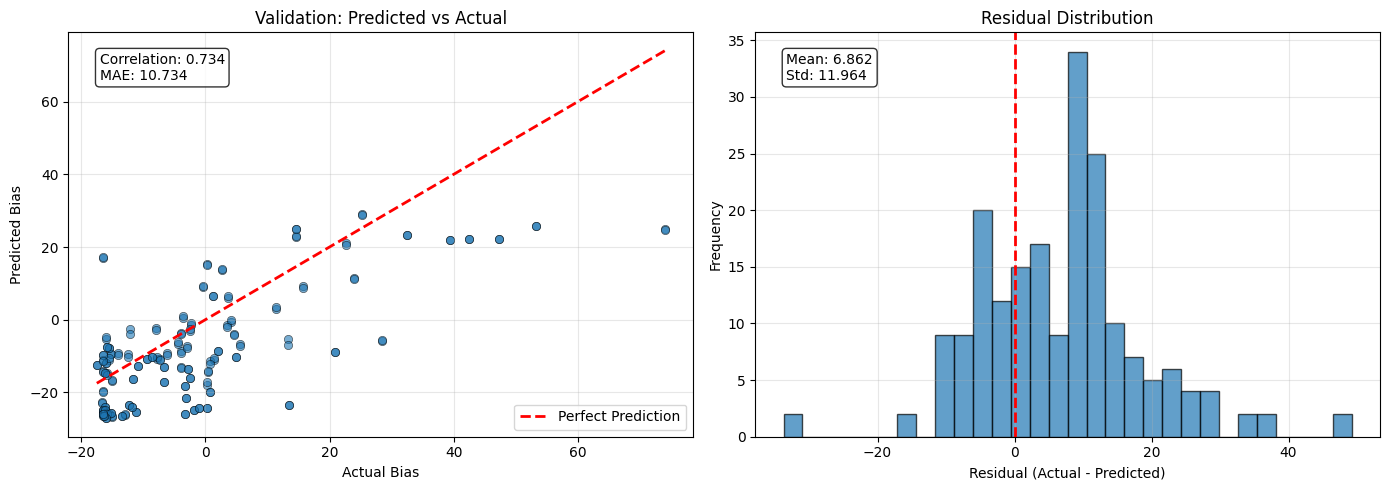

📊 Figure saved to: /content/drive/MyDrive/exercise_danger_data /gnn_bias_distribution.png


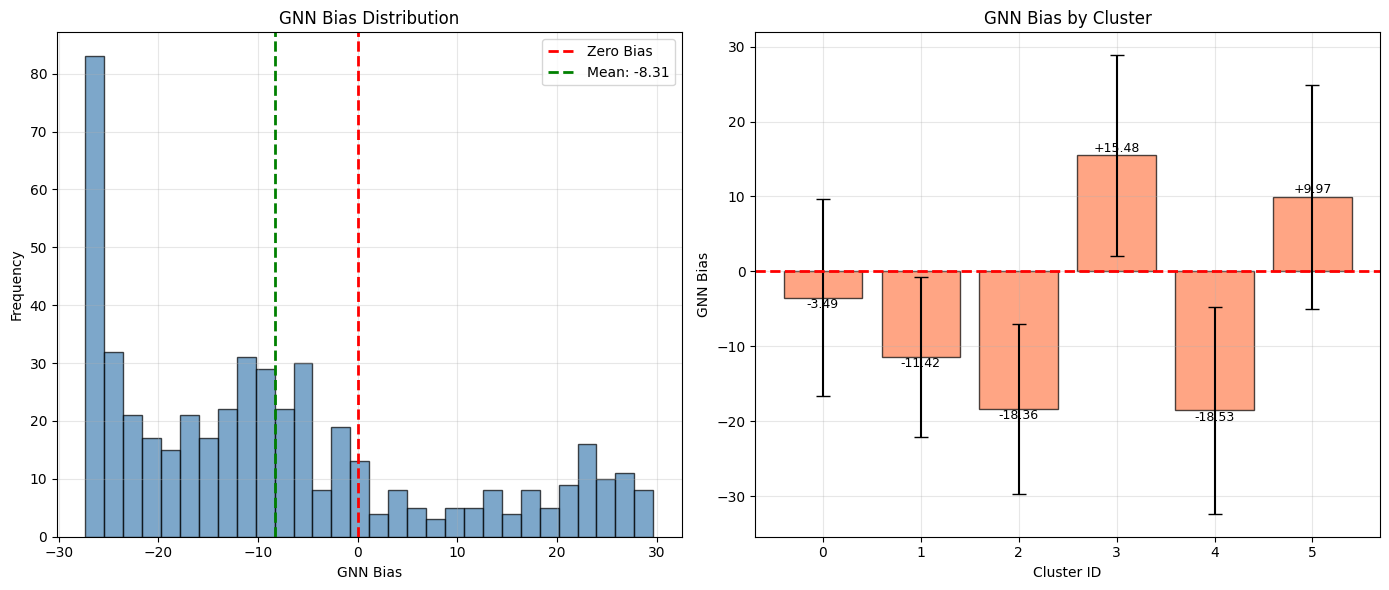


⚙️ Applying Adjustments...
   Aggregating 2 augmentations per location...
   ✅ GNN biases applied
   📊 Final scores: 0.0 - 100.0
   📊 Mean final score: 18.1

💾 Saving to /content/drive/MyDrive/exercise_danger_data /FINAL_EXERCISE_DANGER_SCORES_R.csv...
🎉 Success! Saved 489 rows to /content/drive/MyDrive/exercise_danger_data /FINAL_EXERCISE_DANGER_SCORES_R.csv
   Columns: ['location_name', 'cluster', 'air_quality_PM2.5', 'temperature_celsius', 'air_quality_us-epa-index', 'uv_index', 'math_danger_score', 'gnn_bias', 'final_danger_score', 'final_category']

📊 Cluster Bias Map:
   Cluster 0: -3.49 points
   Cluster 1: -11.42 points
   Cluster 2: -18.36 points
   Cluster 3: +15.48 points
   Cluster 4: -18.53 points
   Cluster 5: +9.97 points


In [ ]:

# RUN THE GNN SYSTEM

if __name__ == "__main__":
    gc.collect()
    torch.cuda.empty_cache()

    # Initialize system
    system = ExerciseDangerGNNSystem()

    try:
        # 1. Load data
        system.load_and_prep_data(augment=True, n_augments=2)

        # 2. Train with monitoring
        history = system.train_gnn_with_monitoring(epochs=3000)

        # 3. Print summary
        print_training_summary(system)

        # 4. Generate plots
        plot_training_history(system, save_path=os.path.join(BASE_PATH, "training_history.png"))
        plot_predictions_vs_targets(system, save_path=os.path.join(BASE_PATH, "predictions_vs_targets.png"))
        visualize_graph_predictions(system, save_path=os.path.join(BASE_PATH, "gnn_bias_distribution.png"))

        # 5. Apply adjustments
        system.apply_adjustments()

        # 6. Save output
        system.save_final_output()

        # 7. Print bias map
        print("\nCluster Bias Map:")
        for cluster, bias in sorted(system.get_bias_map().items()):
            print(f"   Cluster {cluster}: {bias:+.2f} points")

    except Exception as e:
        print(f" Error: {e}")
        import traceback
        traceback.print_exc()

In [21]:
# ============================================================================
# VERIFY THE OUTPUT
# ============================================================================

try:
    df_result = pd.read_csv(OUTPUT_PATH)
    print("📊 Output File Summary:")
    print(f"   Shape: {df_result.shape}")
    print(f"   Columns: {df_result.columns.tolist()}")

    print("\n   Summary Statistics:")
    print(df_result[['math_danger_score', 'gnn_bias', 'final_danger_score']].describe())

    print("\n   Category Distribution:")
    print(df_result['final_category'].value_counts())

except Exception as e:
    print(f"❌ Could not verify output: {e}")

📊 Output File Summary:
   Shape: (489, 10)
   Columns: ['location_name', 'cluster', 'air_quality_PM2.5', 'temperature_celsius', 'air_quality_us-epa-index', 'uv_index', 'math_danger_score', 'gnn_bias', 'final_danger_score', 'final_category']

   Summary Statistics:
       math_danger_score    gnn_bias  final_danger_score
count         489.000000  489.000000          489.000000
mean           21.415644   -8.307591           18.122469
std            18.875759   16.331811           27.126156
min             3.950000  -27.342990            0.000000
25%             6.520000  -22.952140            0.000000
50%            17.870001  -10.908186            3.231932
75%            25.530001   -0.784316           26.544169
max           100.000000   29.654087          100.000000

   Category Distribution:
final_category
SAFE              342
LOW RISK           61
MODERATE RISK      36
EXTREME DANGER     29
HIGH RISK          21
Name: count, dtype: int64
